In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

from readrbdata import load

import matplotlib.pyplot as plt
from fittingutils import *
%matplotlib widget

In [2]:
spike_data = []

In [3]:
sat = load(sat=True, mag=False)
uns = load(sat=False, mag=False)
len(sat.time), len(uns.time)

(13269, 13246)

In [4]:
uns_data_interp = np.interp(sat.time, uns.time, uns.signal)
diff_signal = sat.signal - uns_data_interp

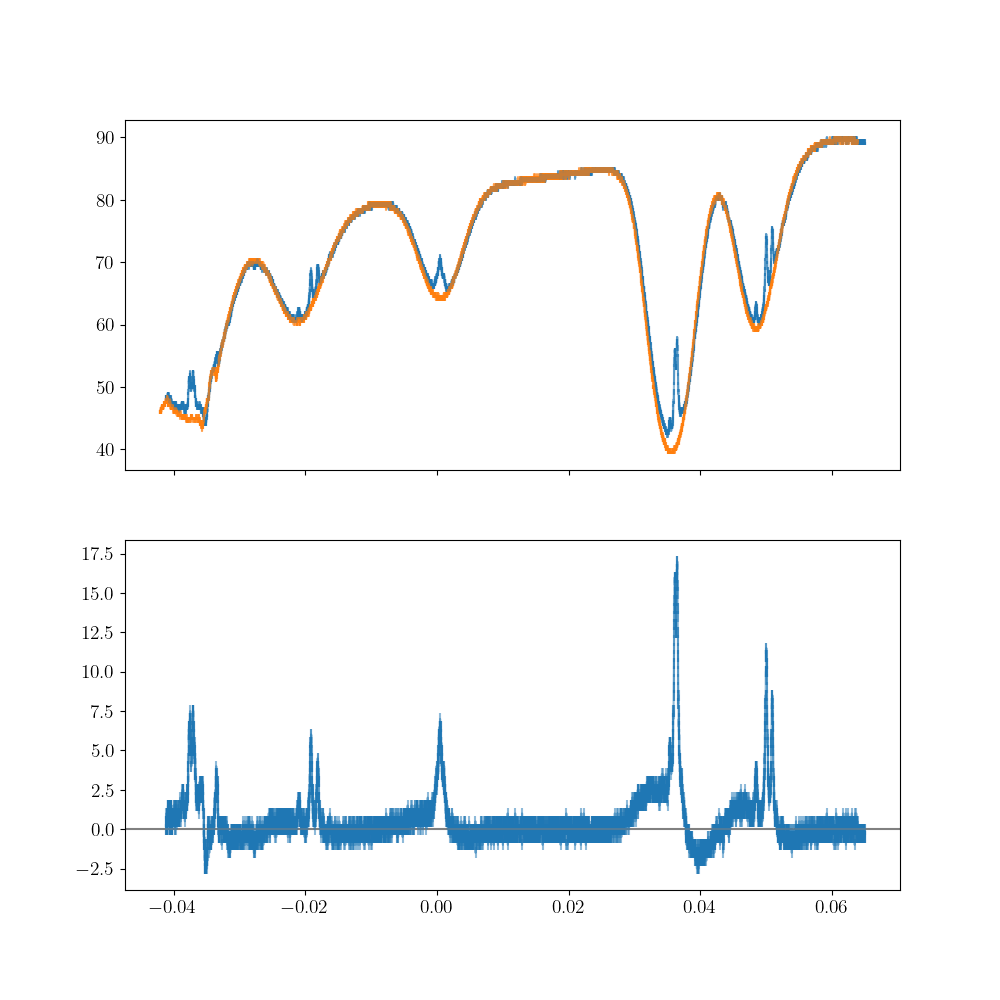

In [5]:
fig, (sig_ax, diff_ax) = plt.subplots(nrows=2, sharex=True, figsize=(10, 10))

sig_ax.errorbar(sat.time, sat.signal, yerr=0.25, alpha=0.5)
sig_ax.errorbar(uns.time, uns.signal, yerr=0.25, alpha=0.5)

diff_ax.errorbar(sat.time, diff_signal, yerr=np.sqrt(2)*0.25, alpha=0.5)
diff_ax.axhline(0., color="gray")

# Fit Ugly One

Fitting this one all at once just because they're so close together

In [6]:
def triple_lorentzian(
        x, 
        x00, g0, a0, 
        x01, g1, a1, 
        x02, g2, a2, 
        offset, offset_slope
):
    return Lorentzian(x, x00, g0, a0, 0.) + Lorentzian(x, x01, g1, a1, 0.) + Lorentzian(x, x02, g2, a2, 0.) + offset + x*offset_slope

len(p0) = 11
fit params:
[ 3.53959466e-02  1.27717680e-04  3.00839047e+00  3.61196615e-02
  1.48704394e-04  1.11510553e+01  3.64857199e-02  1.99224055e-04
  1.36877697e+01  2.19462983e+01 -5.70926874e+02]
cov:
[[ 3.05781210e-11  7.68456727e-13 -7.53978705e-09 -5.76789542e-14
  -2.40617309e-12 -1.75925722e-09 -5.56265155e-13  3.70712313e-13
   4.20213511e-08  2.47556929e-07 -6.63839092e-06]
 [ 7.68456727e-13  8.32204019e-11 -6.80788697e-07 -4.64728863e-13
  -7.12804663e-12 -8.53536650e-09 -1.61894359e-12  3.03487947e-12
   1.81635713e-07 -1.35399183e-06  3.45239008e-05]
 [-7.53978705e-09 -6.80788697e-07  1.67587841e-02 -7.12245946e-09
   4.78215187e-09  6.51504164e-04  1.49066578e-09  6.40746415e-09
   3.96066457e-04 -2.15349257e-03  4.95913990e-02]
 [-5.76789542e-14 -4.64728863e-13 -7.12245946e-09  4.77007774e-12
   3.87781746e-12  1.10139964e-07  2.97644151e-12 -3.87739247e-12
  -1.19853361e-07 -1.55394437e-07  4.66183419e-06]
 [-2.40617309e-12 -7.12804663e-12  4.78215187e-09  3.87781

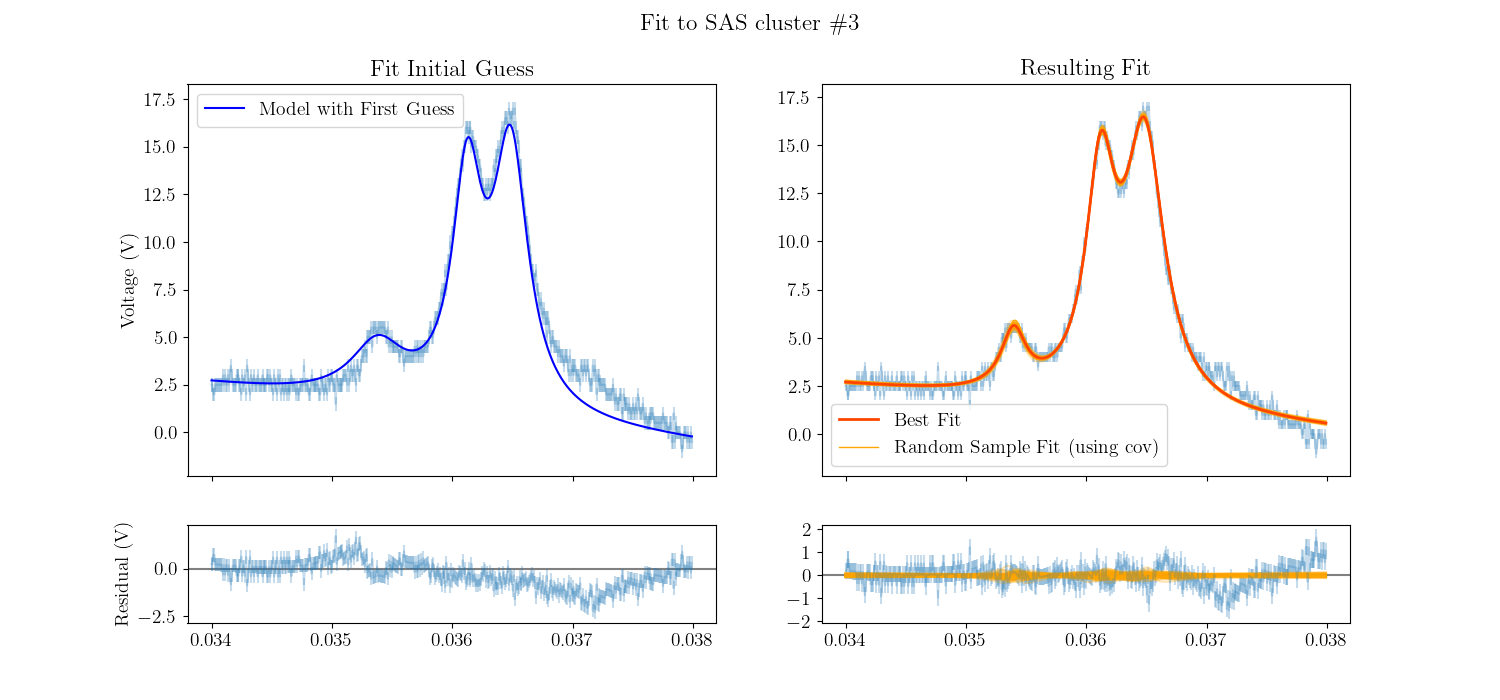

In [7]:
x_low = .034
x_high = .038
cluster_n = 2

# MAKE PLOTS
fig, ((guess_data_ax, fit_data_ax), (guess_res_ax, fit_res_ax)) = plt.subplots(2, 2, sharex=True, height_ratios=[4, 1], figsize=(15, 7))

# ESTABLISH INITIAL GUESSES
spidx, = np.nonzero((x_low <= sat.time) & (sat.time < x_high)) # single peak indices

x = sat.time[spidx]
y = diff_signal[spidx]

baseline_slope_guess = (y[-1] - y[0]) / (x[-1] - x[0])

p0 = [
    3.53802059e-02, 
    2.69989313e-04, 
    2.86606797e+00, 
    
    3.61253841e-02,
    1.48795328e-04, 
    1.16047020e+01, 
    
    3.64869190e-02, 
    1.75914349e-04,
    1.36402594e+01, 
    
    y[0] - baseline_slope_guess * x[0],
    (y[-1] - y[0]) / (x[-1] - x[0])
]
print(f"{len(p0) = }")

guess_data_ax.errorbar(x, y, yerr=np.sqrt(2)*0.25, alpha=0.25)
guess_data_ax.plot(x, triple_lorentzian(x, *p0), zorder=10, color='blue', label='Model with First Guess')

guess_data_ax.set_title('Fit Initial Guess')
guess_data_ax.set_ylabel('Voltage (V)')
guess_data_ax.legend()

residuals = triple_lorentzian(x, *p0) - y

guess_res_ax.axhline(0., color='gray')
guess_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
guess_res_ax.set_ylabel('Residual (V)')
# guess_res_ax.set_ylim(np.min(residuals), np.max(residuals))

fit_params, cov = curve_fit(triple_lorentzian, x, y, p0, np.sqrt(2)*0.25)
print(f"fit params:\n{fit_params}")
print(f"cov:\n{cov}")

fit_data_ax.errorbar(x, y, yerr=0.25, alpha=0.25)
fit_data_ax.plot(x, triple_lorentzian(x, *fit_params), lw=2, c='orangered', zorder=10, label='Best Fit')
data_y_lims = fit_data_ax.set_ylim()

random_fit_samples = np.random.multivariate_normal(fit_params, cov, 64)
for fit_sample in random_fit_samples:
    fit_data_ax.plot(x, triple_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, alpha=0.3)
fit_data_ax.plot(x, triple_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, label='Random Sample Fit (using cov)')

fit_data_ax.legend()

fit_data_ax.set_ylim(data_y_lims)
fit_data_ax.set_title('Resulting Fit')

residuals = triple_lorentzian(x, *fit_params) - y

fit_res_ax.axhline(0., color='gray')
fit_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
for fit_sample in random_fit_samples:
    fit_res_ax.plot(x, triple_lorentzian(x, *fit_sample) - triple_lorentzian(x, *fit_params), c='orange', alpha=0.3)

fig.suptitle(f'Fit to SAS cluster \\#{cluster_n + 1}')

for i in range(3):
    this_spike = {
        "center_time": fit_params[0 + i*3],
        "e_center_time": np.sqrt(np.diag(cov))[0 + i*3],
        "amplitude": fit_params[2 + i*3],
        "cluster_id": cluster_n
    }

    print(f"{this_spike = }")

    if this_spike not in spike_data:
        spike_data.append(this_spike)
    else:
        print('SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE')

    print(f"{len(spike_data) = }")


plt.locator_params(nbins=5)

In [8]:
def red_lorentzian(x, center, gamma, amplitude, baseline, baseline_slope):
    return Lorentzian(x, center, gamma, amplitude, baseline) + baseline_slope*x

In [9]:
def fit_spike(x_low, x_high, cluster_n):
    # MAKE PLOTS
    fig, ((guess_data_ax, fit_data_ax), (guess_res_ax, fit_res_ax)) = plt.subplots(2, 2, sharex=True, height_ratios=[4, 1], figsize=(15, 7))

    # ESTABLISH INITIAL GUESSES
    spidx, = np.nonzero((x_low <= sat.time) & (sat.time < x_high)) # single peak indices

    x = sat.time[spidx]
    y = diff_signal[spidx]

    center_guess = x[np.argmax(diff_signal[spidx])]
    slope_guess = (y[-1] - y[0]) / (x[-1] - x[0])

    p0 = [
        center_guess,
        Lorentzian.guess_gamma(x, y),
        np.max(y) - (slope_guess*(center_guess - x[0]) + y[0]),
        y[0] - slope_guess*x[0],
        slope_guess
    ]
    print(f"{p0 = }")

    guess_data_ax.errorbar(x, y, yerr=np.sqrt(2)*0.25, alpha=0.25)
    guess_data_ax.plot(x, red_lorentzian(x, *p0), zorder=10, color='blue')

    # guess_data_ax.axvline(p0[0], label='x0 guess', c='red', alpha=0.5)
    # guess_data_ax.plot([p0[0] - p0[1], p0[0] + p0[1]], [(p0[2] + p0[3] + slope_guess*x[0])/2, (p0[2] + p0[3] + slope_guess*x[0])/2], color='green', alpha=0.5, label='FWHM guess')
    # # guess_data_ax.axhline(p0[2] + p0[3] + slope_guess*x[0], label='amplitude guess', c='red', alpha=0.5)
    # guess_data_ax.axline(slope_guess*(center_guess - x[0]) + y[0], slope=slope_guess)
    # guess_data_ax.axhline(p0[3] + slope_guess*x[0], label='baseline guess', c='red', alpha=0.5)

    guess_data_ax.set_title('Fit Initial Guess')
    guess_data_ax.set_ylabel('Voltage (V)')
    guess_data_ax.legend()

    residuals = red_lorentzian(x, *p0) - y

    guess_res_ax.axhline(0., color='gray')
    guess_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
    guess_res_ax.set_ylabel('Residual (V)')
    # guess_res_ax.set_ylim(np.min(residuals), np.max(residuals))
    
    fit_params, cov = curve_fit(red_lorentzian, x, y, p0, np.sqrt(2)*0.25)
    print(f"fit params:\n{fit_params}")
    print(f"cov:\n{cov}")

    fit_data_ax.errorbar(x, y, yerr=0.25, alpha=0.25)
    fit_data_ax.plot(x, red_lorentzian(x, *fit_params), lw=2, c='orangered', zorder=10, label='Best Fit')
    data_y_lims = fit_data_ax.set_ylim()

    random_fit_samples = np.random.multivariate_normal(fit_params, cov, 64)
    for fit_sample in random_fit_samples:
        fit_data_ax.plot(x, red_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5)
    fit_data_ax.plot(x, red_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, label='Random Sample Fit (using cov)')
    
    fit_data_ax.legend()

    fit_data_ax.set_ylim(data_y_lims)
    fit_data_ax.set_title('Resulting Fit')

    residuals = red_lorentzian(x, *fit_params) - y

    fit_res_ax.axhline(0., color='gray')
    fit_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
    for fit_sample in random_fit_samples:
        fit_res_ax.plot(x, red_lorentzian(x, *fit_sample) - red_lorentzian(x, *fit_params), c='orange')

    fig.suptitle(f'Fit to SAS cluster \\#{cluster_n + 1}')
    np.sqrt(np.diag(cov))
    this_spike = {
        "center_time": fit_params[0],
        "e_center_time": np.sqrt(np.diag(cov))[0],
        "amplitude": fit_params[2],
        "cluster_id": cluster_n
    }

    print(f"{this_spike = }")

    if this_spike not in spike_data:
        spike_data.append(this_spike)
    else:
        print('SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE')

    print(f"{len(spike_data) = }")
    plt.locator_params(nbins=5)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [-0.021064, 0.00010000000000000113, 1.5, 0.5, 0.0]
fit params:
[-2.09698342e-02  1.67905843e-04  1.71598209e+00 -1.27220487e+00
 -7.10153021e+01]
cov:
[[ 5.57618038e-11  1.12231774e-12  2.68131122e-09 -1.26356975e-06
  -6.00229748e-05]
 [ 1.12231774e-12  1.92875196e-10 -4.20782603e-07 -8.05858475e-07
  -2.35370688e-05]
 [ 2.68131122e-09 -4.20782603e-07  5.69740972e-03 -1.62801861e-03
  -5.62183731e-02]
 [-1.26356975e-06 -8.05858475e-07 -1.62801861e-03  5.14241239e-01
   2.43659735e+01]
 [-6.00229748e-05 -2.35370688e-05 -5.62183731e-02  2.43659735e+01
   1.15705533e+03]]
this_spike = {'center_time': -0.020969834212258915, 'e_center_time': 7.467382662546673e-06, 'amplitude': 1.7159820878758059, 'cluster_id': 0}
len(spike_data) = 4


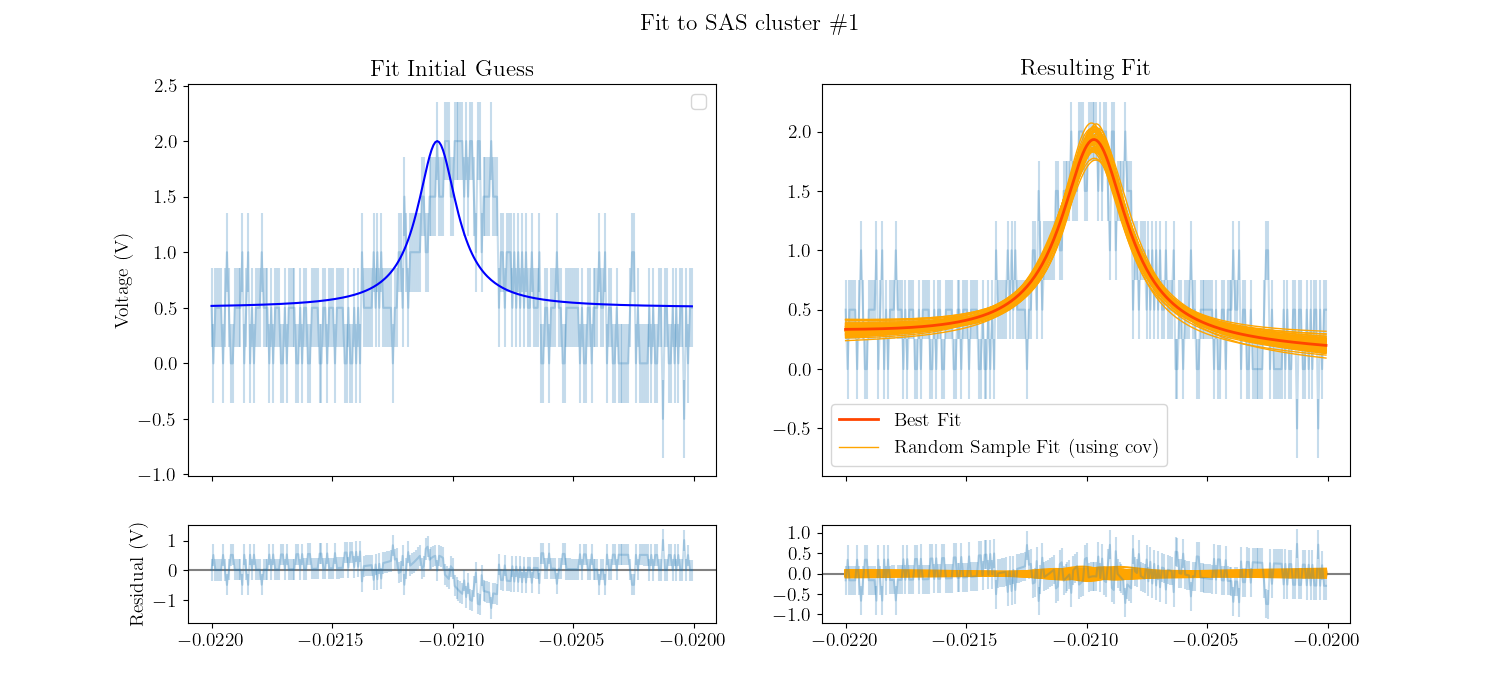

In [10]:
fit_spike(-.022, -.02, 0)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [-0.019136, 0.00015199999999999936, 5.189655172413794, 7.683908045977007, 359.19540229885035]
fit params:
[-1.91517130e-02  1.77564087e-04  5.71231649e+00 -1.38185468e-01
 -1.17389206e+01]
cov:
[[ 7.08683982e-12  2.36102857e-12  2.94306794e-08 -1.65001989e-06
  -8.39857452e-05]
 [ 2.36102857e-12  3.46296936e-11  6.28531278e-10 -3.84785351e-06
  -1.83756845e-04]
 [ 2.94306794e-08  6.28531278e-10  8.04021868e-03 -4.72714788e-02
  -2.31029670e+00]
 [-1.65001989e-06 -3.84785351e-06 -4.72714788e-02  2.30284887e+00
   1.16734525e+02]
 [-8.39857452e-05 -1.83756845e-04 -2.31029670e+00  1.16734525e+02
   5.92559046e+03]]
this_spike = {'center_time': -0.019151712963842833, 'e_center_time': 2.662111908858146e-06, 'amplitude': 5.712316488837224, 'cluster_id': 0}
len(spike_data) = 5


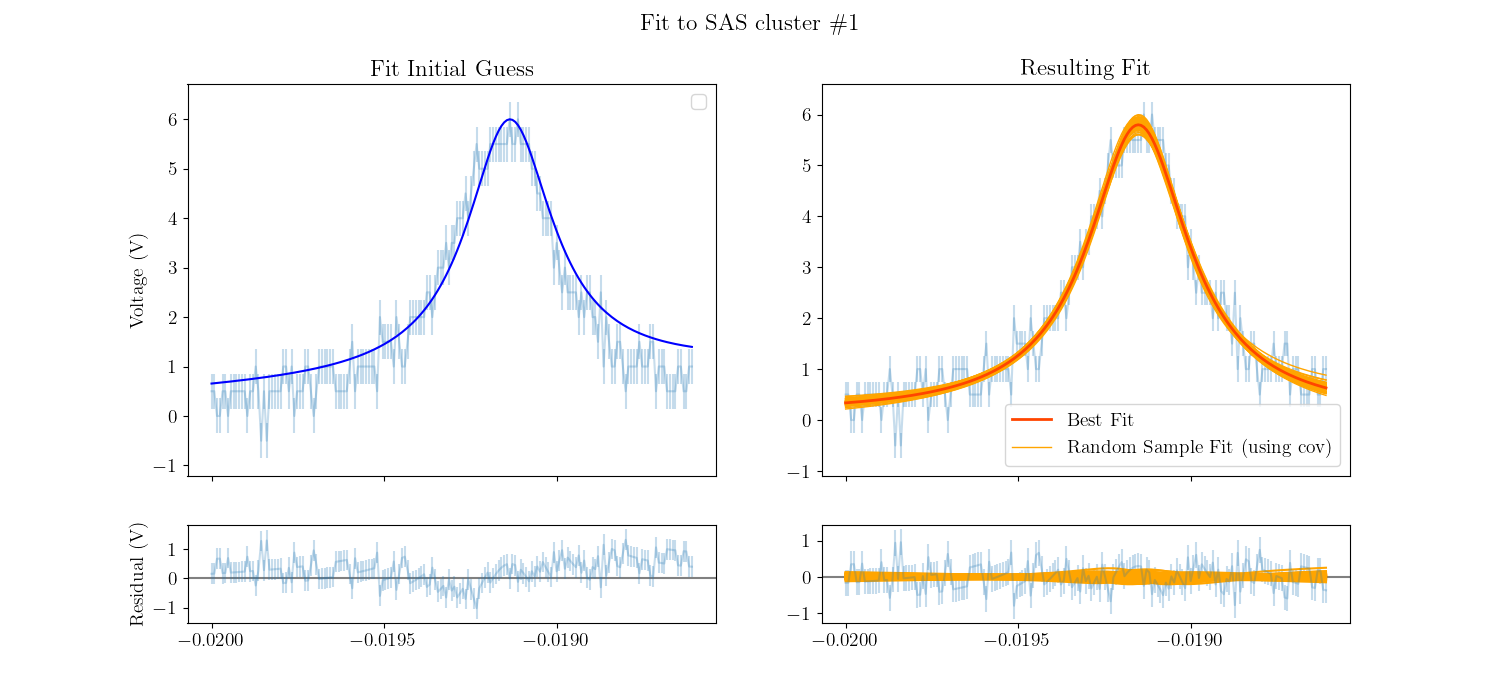

In [11]:
fit_spike(-.02, -.01860, 0)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [-0.018144, 0.00015199999999999936, 4.0, 0.5, 0.0]
fit params:
[-1.81212676e-02  1.71915196e-04  4.13177270e+00 -1.99128510e+00
 -1.08865596e+02]
cov:
[[ 1.54651264e-11 -4.24454775e-12 -4.69722677e-08 -3.73992050e-06
  -2.09788608e-04]
 [-4.24454775e-12  8.36227391e-11  1.45283989e-07  4.36396273e-06
   2.78795700e-04]
 [-4.69722677e-08  1.45283989e-07  1.04598476e-02  5.07074729e-02
   3.09572963e+00]
 [-3.73992050e-06  4.36396273e-06  5.07074729e-02  3.81366129e+00
   2.14058250e+02]
 [-2.09788608e-04  2.78795700e-04  3.09572963e+00  2.14058250e+02
   1.20366987e+04]]
this_spike = {'center_time': -0.018121267608885744, 'e_center_time': 3.932572486416992e-06, 'amplitude': 4.131772700385358, 'cluster_id': 0}
len(spike_data) = 6


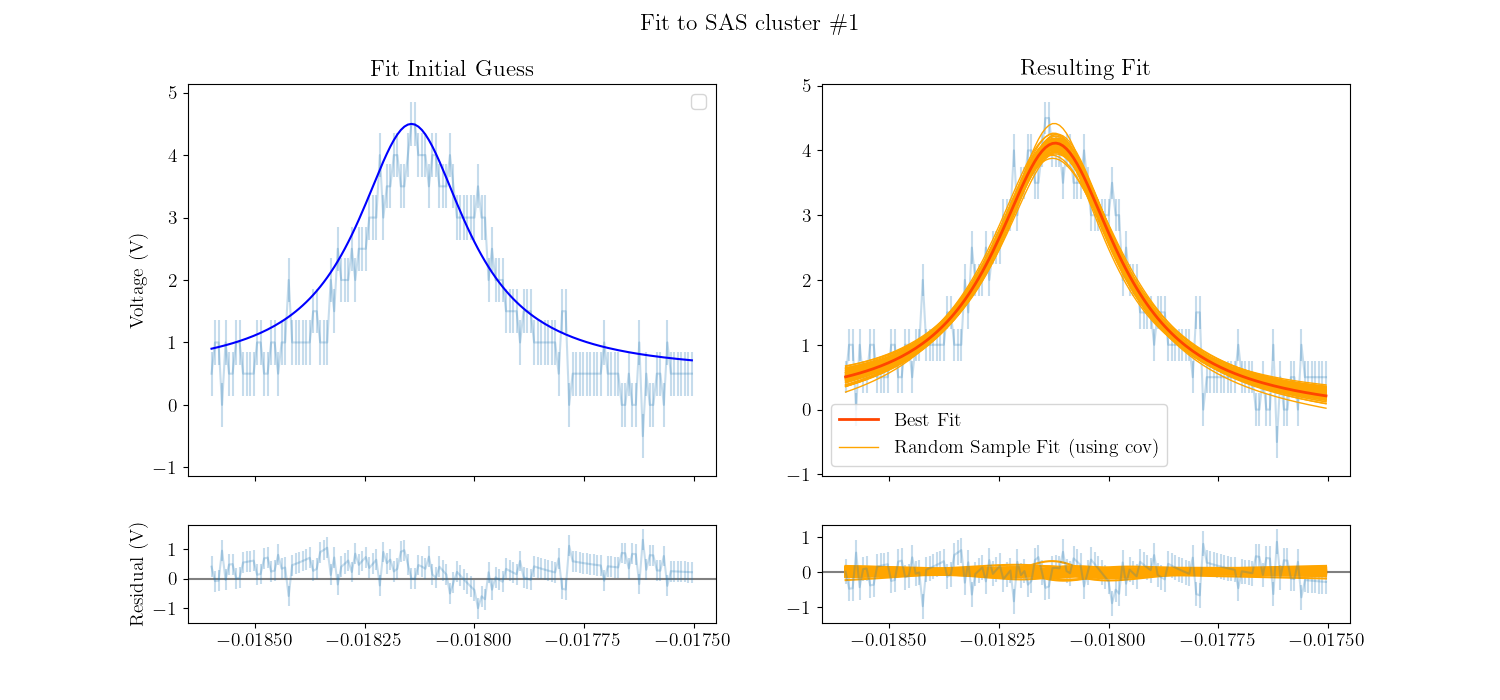

In [12]:
fit_spike(-.01860, -.01750, 0)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [0.000472, 0.000288, 6.55955955955956, 0.49949949949949946, -125.12512512512514]
fit params:
[ 4.73019854e-04  5.41149973e-04  5.89587442e+00  1.28609038e-01
 -1.80851140e+02]
cov:
[[ 2.36099710e-11  1.08143737e-12  2.22087449e-09 -2.37146690e-09
  -4.75925532e-06]
 [ 1.08143737e-12  7.47907517e-11 -2.14681153e-07 -1.01654995e-07
  -7.06356530e-06]
 [ 2.22087449e-09 -2.14681153e-07  2.76134443e-03 -1.24594948e-04
  -1.45261312e-02]
 [-2.37146690e-09 -1.01654995e-07 -1.24594948e-04  3.62966346e-04
   1.64384362e-02]
 [-4.75925532e-06 -7.06356530e-06 -1.45261312e-02  1.64384362e-02
   2.91123829e+01]]
this_spike = {'center_time': 0.00047301985351782784, 'e_center_time': 4.85900926145588e-06, 'amplitude': 5.895874423056896, 'cluster_id': 1}
len(spike_data) = 7


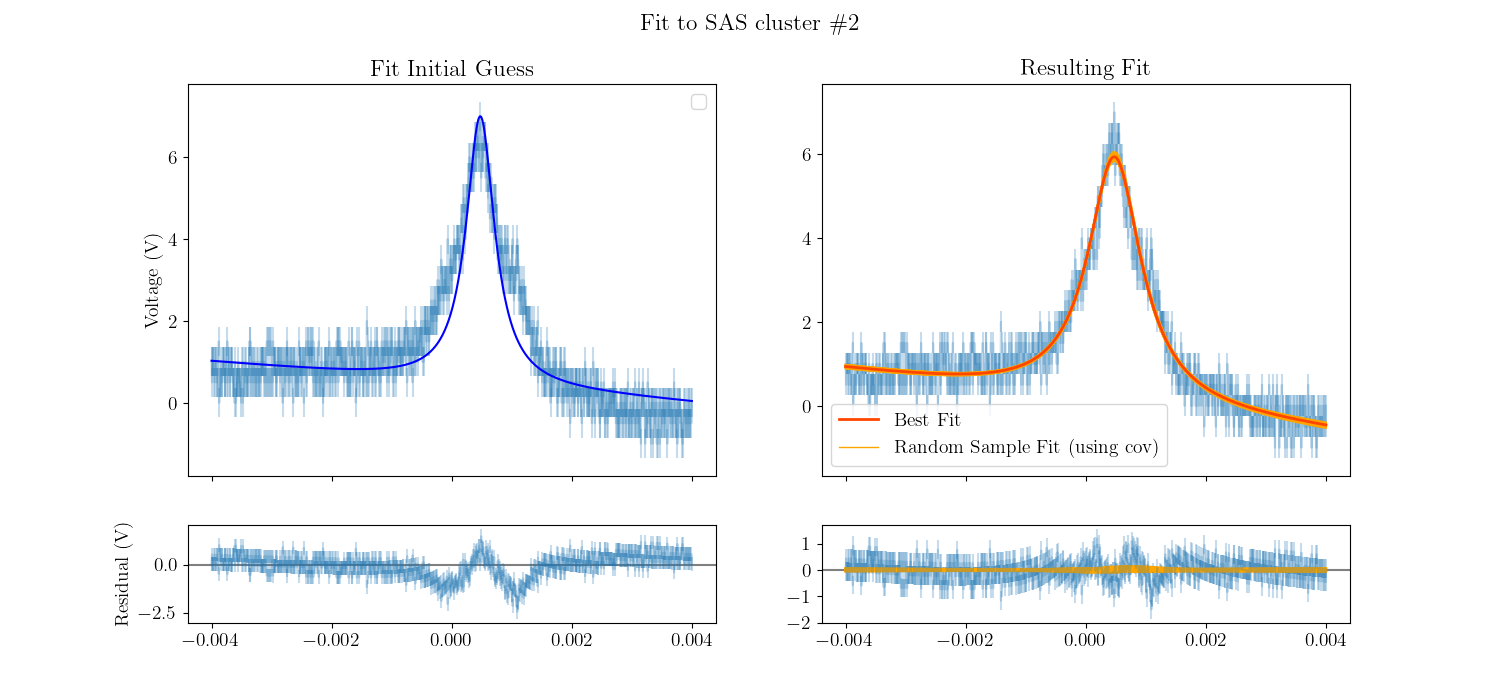

In [13]:
fit_spike(-.004, .004, 1)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [0.048448, 0.0001360000000000007, 3.0, 1.0, 0.0]
fit params:
[ 4.84816364e-02  1.55610041e-04  3.24109222e+00  6.30070004e+00
 -1.15276271e+02]
cov:
[[ 1.84469835e-11  7.64331643e-13  4.67978782e-09  3.79141229e-06
  -7.83585453e-05]
 [ 7.64331643e-13  7.23523428e-11 -2.10063156e-07  1.55034217e-06
  -3.83105546e-05]
 [ 4.67978782e-09 -2.10063156e-07  7.85043520e-03  1.01944346e-02
  -2.34546284e-01]
 [ 3.79141229e-06  1.55034217e-06  1.01944346e-02  8.27914949e+00
  -1.71095280e+02]
 [-7.83585453e-05 -3.83105546e-05 -2.34546284e-01 -1.71095280e+02
   3.53686763e+03]]
this_spike = {'center_time': 0.048481636375307155, 'e_center_time': 4.294995172502165e-06, 'amplitude': 3.241092219291514, 'cluster_id': 3}
len(spike_data) = 8


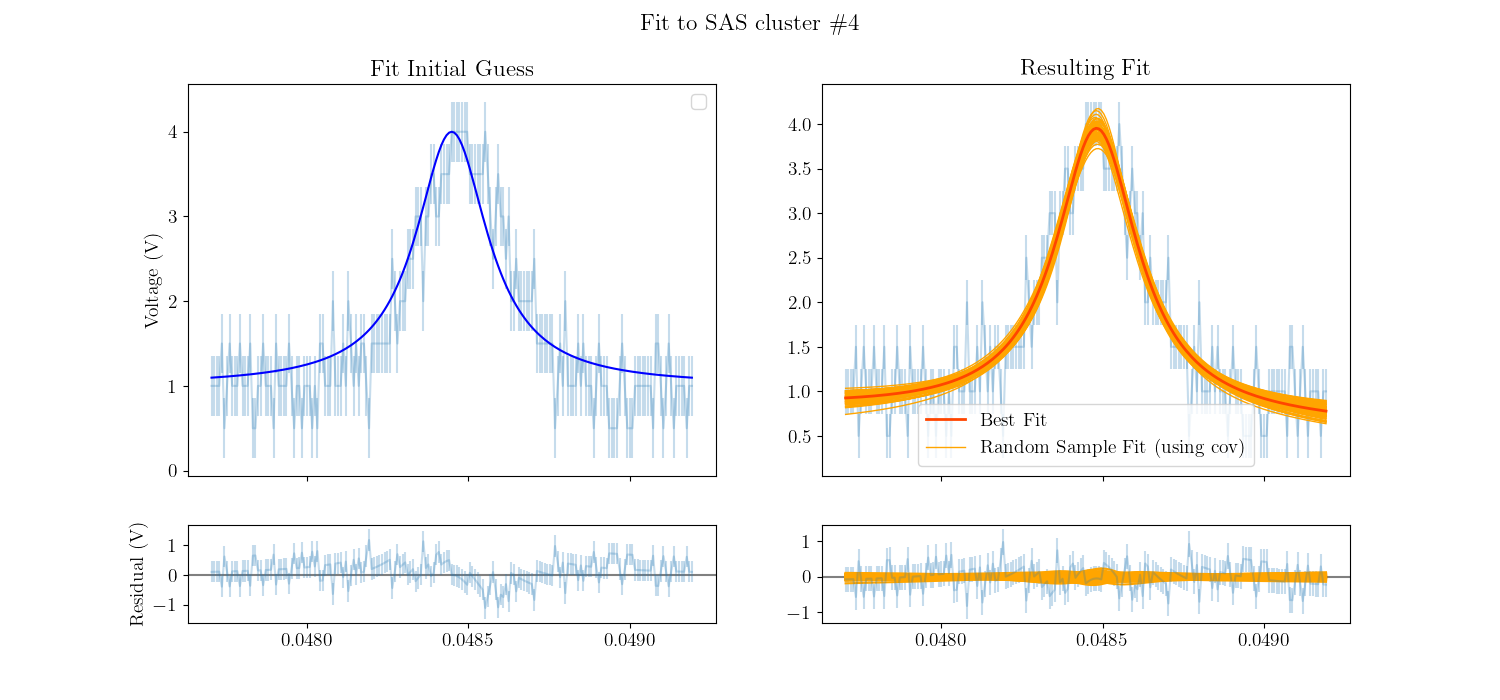

In [14]:
fit_spike(.0477, .0492, 3)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [0.05004, 0.00018400000000000014, 9.693467336683415, -61.057788944723775, 1256.281407035179]
fit params:
[ 5.00269530e-02  1.78274435e-04  1.06439113e+01 -1.15106564e+01
  2.43151532e+02]
cov:
[[ 2.25373187e-12  8.18637799e-13  1.72822360e-08  1.95655505e-06
  -3.96184554e-05]
 [ 8.18637799e-13  1.07617405e-11 -1.40575439e-08  5.51478678e-06
  -1.13839573e-04]
 [ 1.72822360e-08 -1.40575439e-08  8.80736754e-03  1.18918840e-01
  -2.43637828e+00]
 [ 1.95655505e-06  5.51478678e-06  1.18918840e-01  1.24211391e+01
  -2.51753016e+02]
 [-3.96184554e-05 -1.13839573e-04 -2.43637828e+00 -2.51753016e+02
   5.10357099e+03]]
this_spike = {'center_time': 0.05002695301487994, 'e_center_time': 1.5012434423995213e-06, 'amplitude': 10.643911325938866, 'cluster_id': 3}
len(spike_data) = 9


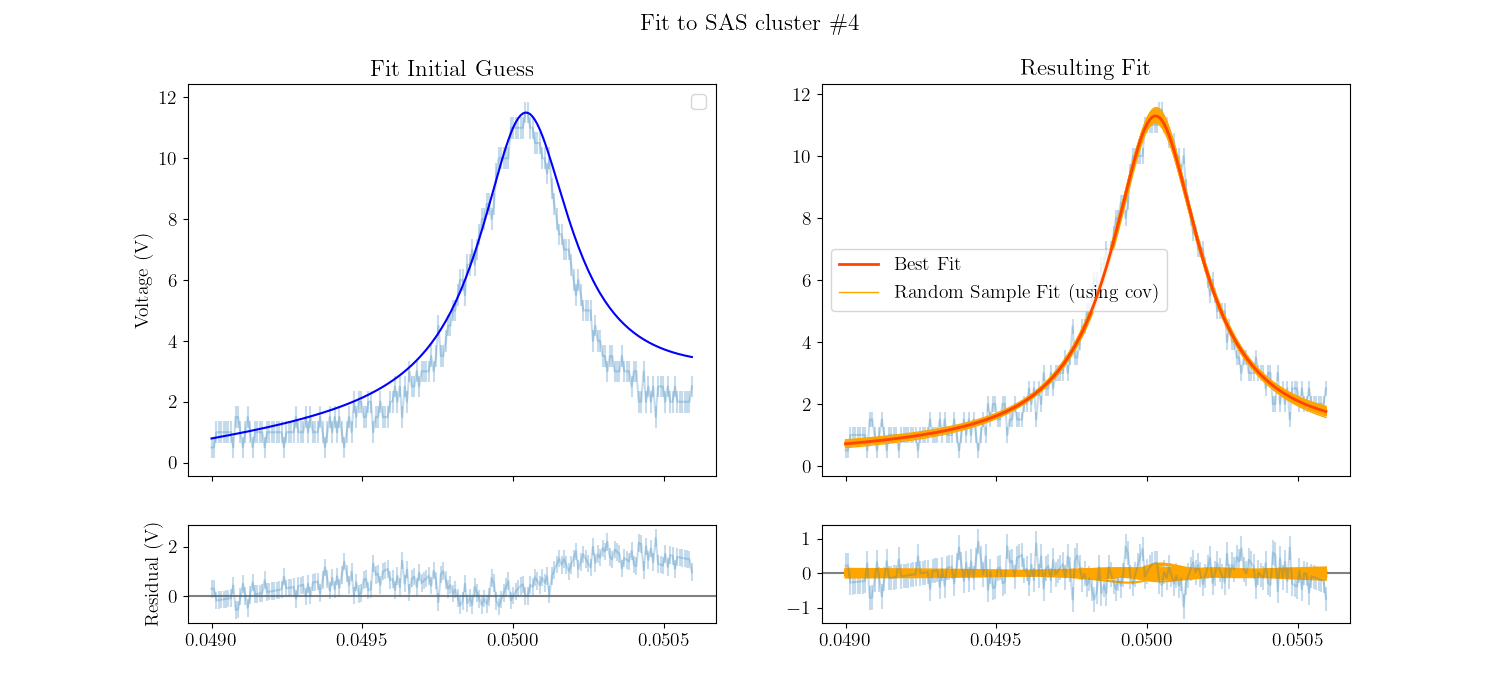

In [15]:
fit_spike(.04900, .0506, 3)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p0 = [0.050912, 0.00017199999999999854, 6.705645161290322, 27.455645161290327, -504.0322580645162]
fit params:
[ 5.09281678e-02  1.62623373e-04  8.01038539e+00  4.22494599e+01
 -8.21728728e+02]
cov:
[[ 4.72802397e-12 -1.63830597e-12 -3.92097039e-08  8.16173999e-06
  -1.59268816e-04]
 [-1.63830597e-12  2.67333887e-11  1.39903473e-07 -1.27590897e-05
   2.41070153e-04]
 [-3.92097039e-08  1.39903473e-07  1.42890710e-02 -3.03518848e-01
   5.79579240e+00]
 [ 8.16173999e-06 -1.27590897e-05 -3.03518848e-01  5.39803454e+01
  -1.05224103e+03]
 [-1.59268816e-04  2.41070153e-04  5.79579240e+00 -1.05224103e+03
   2.05150395e+04]]
this_spike = {'center_time': 0.050928167808013056, 'e_center_time': 2.174401979695329e-06, 'amplitude': 8.010385392924046, 'cluster_id': 3}
len(spike_data) = 10


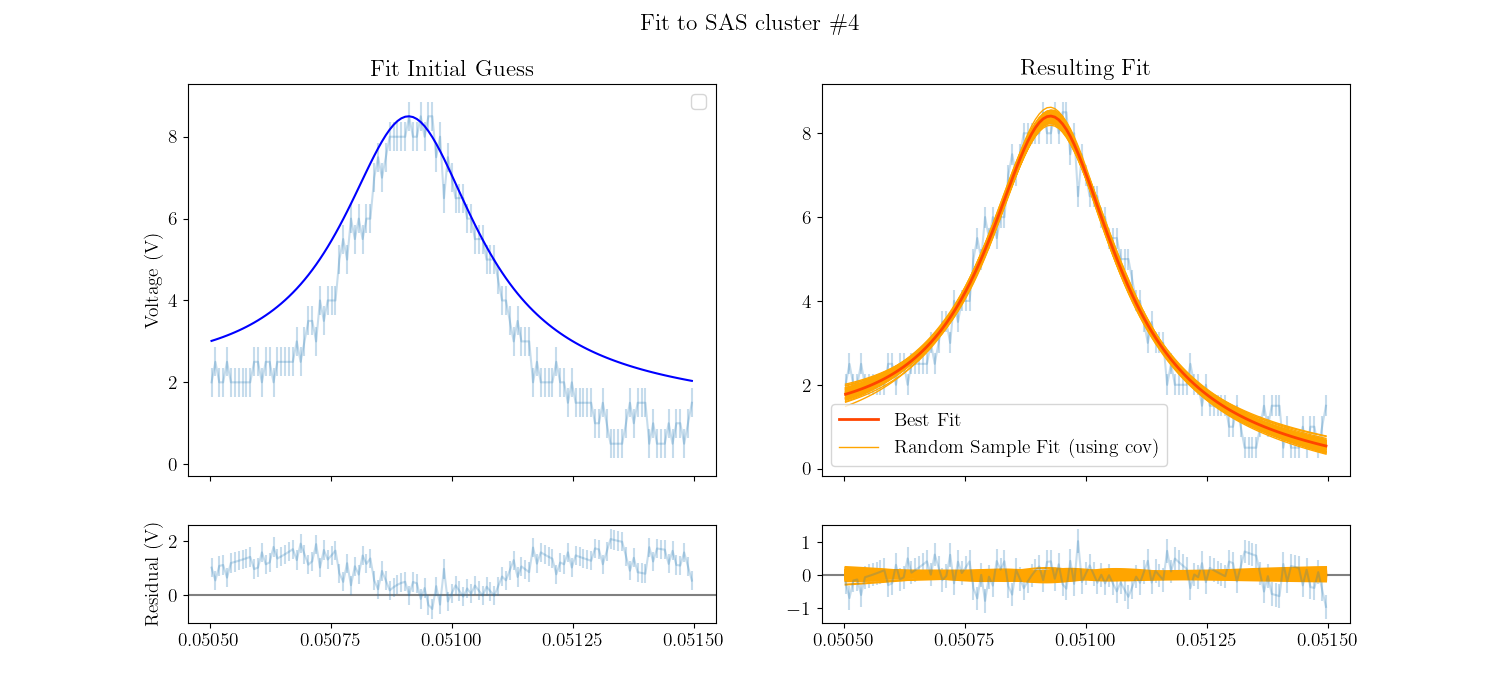

In [16]:
fit_spike(.0505, .0515, 3)

In [17]:
df = pd.DataFrame(spike_data).sort_values('center_time').reset_index(drop=True)
df

,center_time,e_center_time,amplitude,cluster_id
0,-0.020970,0.000007,1.715982,0
1,-0.019152,0.000003,5.712316,0
2,-0.018121,0.000004,4.131773,0
3,0.000473,0.000005,5.895874,1
4,0.035396,0.000006,3.008390,2
5,0.036120,0.000002,11.151055,2
6,0.036486,0.000002,13.687770,2
7,0.048482,0.000004,3.241092,3
8,0.050027,0.000002,10.643911,3
9,0.050928,0.000002,8.010385,3


In [18]:
df.to_csv('sas_spike_data_time.csv', index=False)